# Demand Forecasting - Exploratory Data Analysis

This notebook explores the Rossmann Store Sales dataset to understand temporal patterns, seasonality, and external factors that influence demand.

**Key questions:**
- What are the dominant time patterns (weekly, monthly, yearly)?
- Is the sales series stationary or non-stationary?
- How do promotions and holidays affect demand?
- Are there differences across store types?

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {'primary': '#2563eb', 'secondary': '#dc2626', 'tertiary': '#059669', 'neutral': '#64748b'}

## 1. Load and Inspect the Data

In [30]:
train = pd.read_csv('/kaggle/input/datasets/nehamalik10/demand-forecasting-dataset/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('/kaggle/input/datasets/nehamalik10/demand-forecasting-dataset/store.csv')

df_raw = train.merge(store, on='Store', how='left')
df_raw = df_raw.sort_values(['Store', 'Date']).reset_index(drop=True)

print(f'Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'Date range: {df_raw["Date"].min()} to {df_raw["Date"].max()}')
print(f'Stores: {df_raw["Store"].nunique()}')

Shape: 1,017,209 rows, 18 columns
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Stores: 1115


In [31]:
df_raw.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
5,1,7,2013-01-06,0,0,0,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
6,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
7,1,2,2013-01-08,5580,654,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
8,1,3,2013-01-09,5471,626,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
9,1,4,2013-01-10,4892,615,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [32]:
# Remove closed-store days: Sales=0 when Open=0 is an operational decision,
# not a demand signal. Including these would bias the model toward predicting zeros.
df = df_raw[df_raw['Open'] == 1].copy()

# Handle missing values
max_dist = df['CompetitionDistance'].max()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(max_dist * 2)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0).astype(int)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0).astype(int)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0).astype(int)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0).astype(int)
df['PromoInterval'] = df['PromoInterval'].fillna('')

# Extract calendar features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek_num'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['DayOfWeek_num'] >= 5).astype(int)

print(f'\nCleaned: {len(df):,} rows (removed {len(df_raw) - len(df):,} closed-store days)')
print(f'Missing values: {df.isnull().sum().sum()}')


Cleaned: 844,392 rows (removed 172,817 closed-store days)
Missing values: 0


In [33]:
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Day,DayOfWeek_num,WeekOfYear,IsWeekend
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,2014-04-11 01:02:42.487565312,6955.514291,762.728395,1.0,0.446352,0.193580,5836.629326,4.926491,1369.688401,0.498684,11.596118,1003.230065,2013.831937,5.845738,15.835683,2.520361,23.646801,0.174861
min,1.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,3.000000,8.000000,1.000000,11.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2330.000000,4.000000,2006.000000,0.000000,0.000000,0.000000,2014.000000,6.000000,16.000000,2.000000,23.000000,0.000000
75%,837.000000,5.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6910.000000,9.000000,2011.000000,1.000000,22.000000,2012.000000,2014.000000,8.000000,23.000000,4.000000,35.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,151720.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000,2015.000000,12.000000,31.000000,6.000000,52.000000,1.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.395103,10773.494513,4.283663,935.558173,0.499999,15.307873,1005.874806,0.777260,3.323931,8.683456,1.723689,14.389785,0.379848


## 2. Time Series Overview

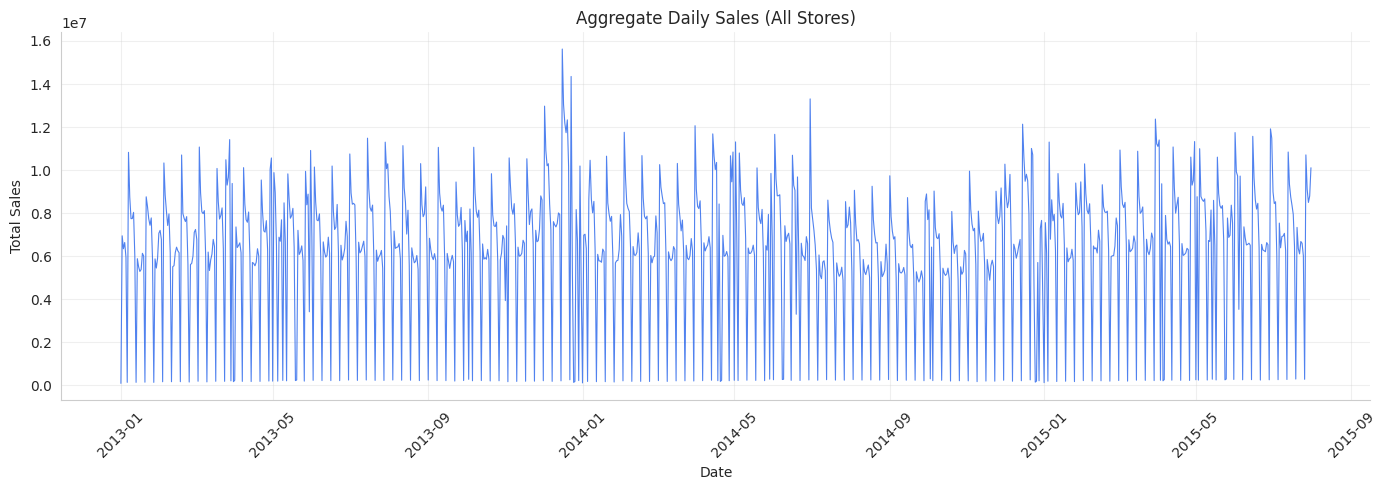

In [34]:
# Aggregate daily sales across all stores
daily = df.groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['Date'], daily['Sales'], color=COLORS['primary'], lw=0.8, alpha=0.8)
ax.set_title('Aggregate Daily Sales (All Stores)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

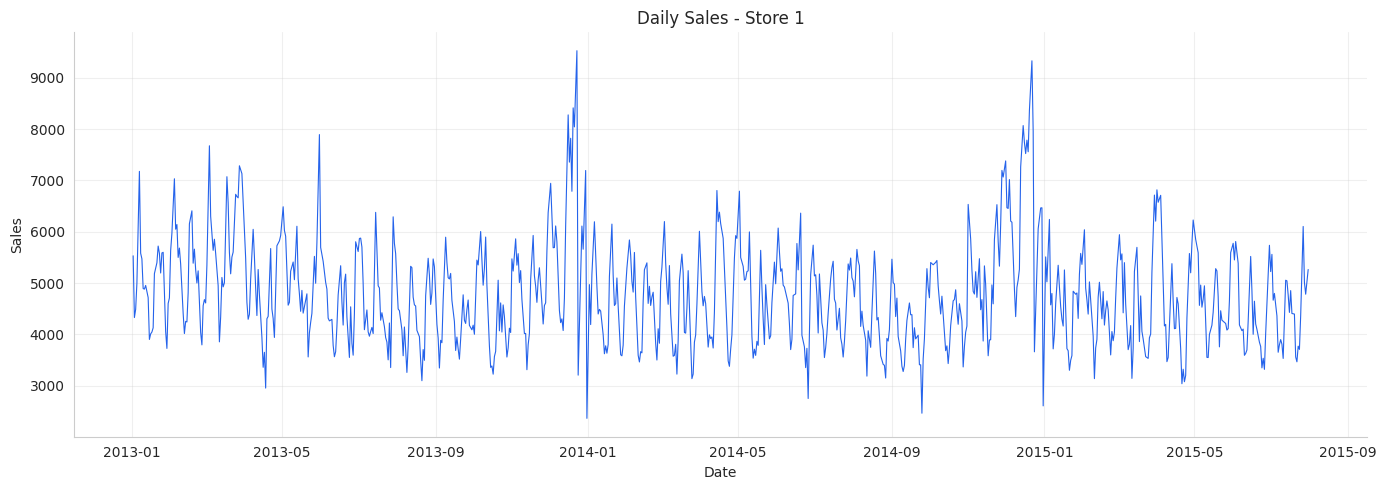

In [35]:
# Single store view for clearer pattern identification
store_1 = df[df['Store'] == 1].set_index('Date')['Sales']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(store_1.index, store_1.values, color=COLORS['primary'], lw=0.8)
ax.set_title('Daily Sales - Store 1')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Weekly Seasonality

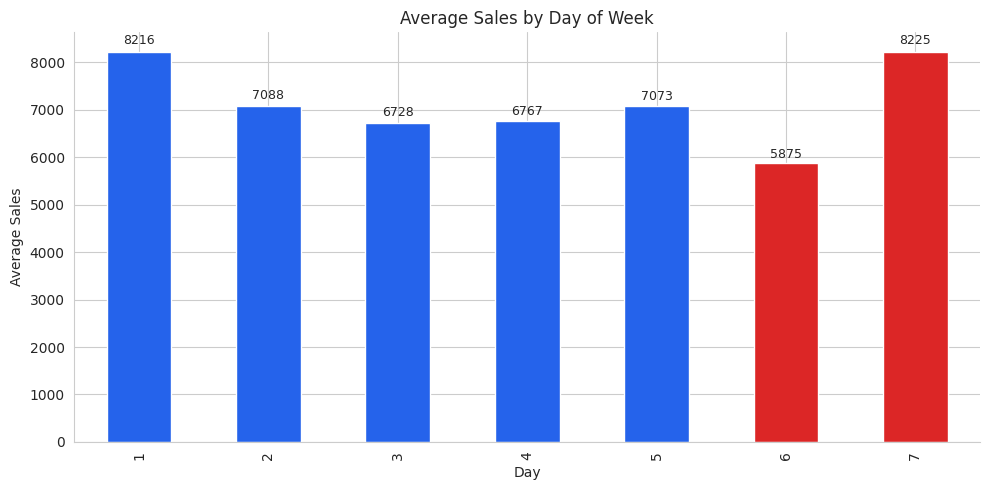

In [36]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly = df.groupby('DayOfWeek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['primary']] * 5 + [COLORS['secondary']] * 2
weekly.plot(kind='bar', ax=ax, color=colors[:len(weekly)], edgecolor='white')
ax.set_title('Average Sales by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Average Sales')
for i, v in enumerate(weekly):
    ax.text(i, v + v * 0.02, f'{v:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Monthly and Yearly Trends

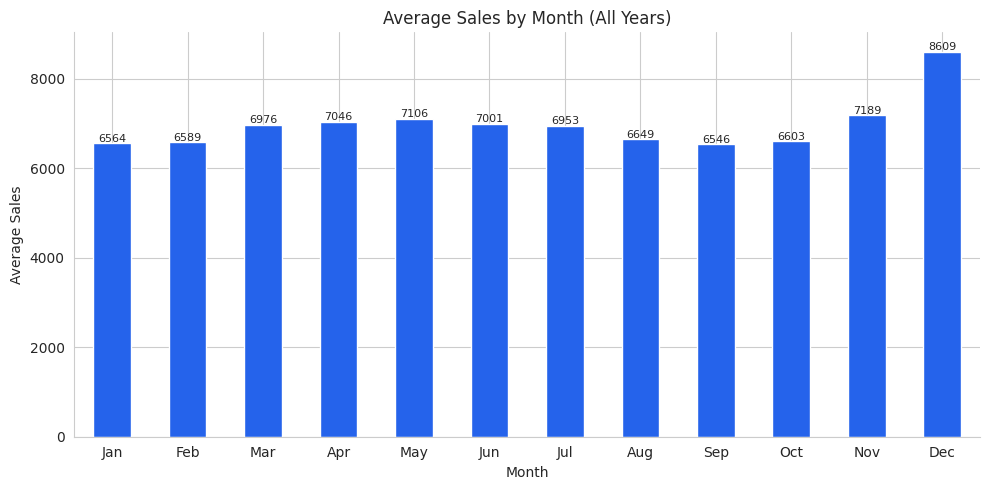

In [37]:
monthly_avg = df.groupby('Month')['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg.plot(kind='bar', ax=ax, color=COLORS['primary'], edgecolor='white')
ax.set_title('Average Sales by Month (All Years)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Sales')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
for i, v in enumerate(monthly_avg):
    ax.text(i, v + 30, f'{v:.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Promotion and Holiday Impact

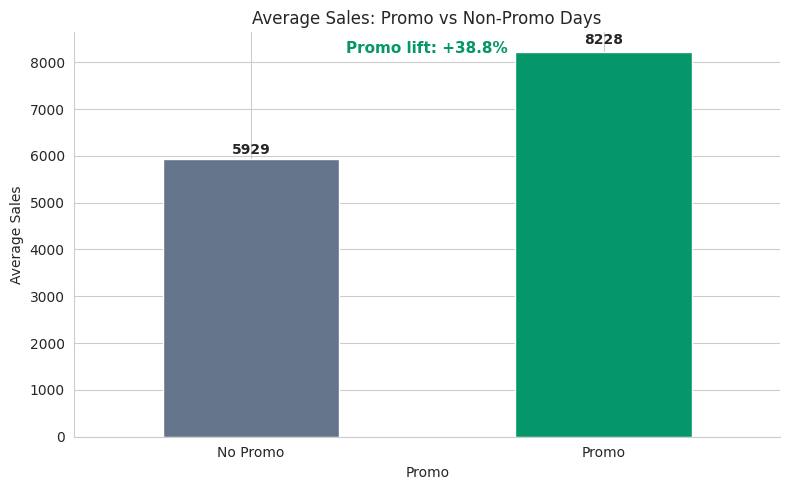

In [38]:
# Promo impact
promo_sales = df.groupby('Promo')['Sales'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
promo_sales.plot(kind='bar', ax=ax, color=[COLORS['neutral'], COLORS['tertiary']], edgecolor='white')
ax.set_title('Average Sales: Promo vs Non-Promo Days')
ax.set_xticklabels(['No Promo', 'Promo'], rotation=0)
ax.set_ylabel('Average Sales')
for i, v in enumerate(promo_sales):
    ax.text(i, v + v * 0.02, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

if len(promo_sales) == 2:
    lift = (promo_sales.iloc[1] / promo_sales.iloc[0] - 1) * 100
    ax.text(0.5, 0.95, f'Promo lift: +{lift:.1f}%',
            transform=ax.transAxes, ha='center', fontsize=11,
            fontweight='bold', color=COLORS['tertiary'])
plt.tight_layout()
plt.show()

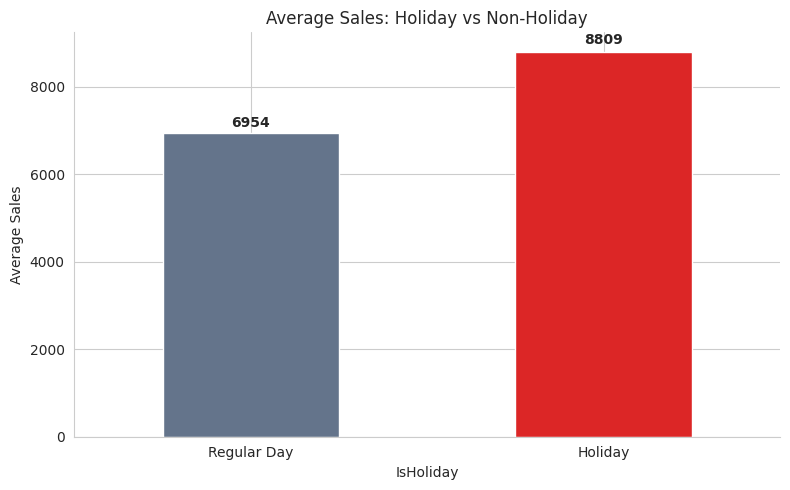

In [39]:
# Holiday impact
df['IsHoliday'] = ((df['StateHoliday'] != '0') & (df['StateHoliday'] != 0)).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
holiday_sales = df.groupby('IsHoliday')['Sales'].mean()
holiday_sales.plot(kind='bar', ax=ax, color=[COLORS['neutral'], COLORS['secondary']], edgecolor='white')
ax.set_title('Average Sales: Holiday vs Non-Holiday')
ax.set_xticklabels(['Regular Day', 'Holiday'], rotation=0)
ax.set_ylabel('Average Sales')
for i, v in enumerate(holiday_sales):
    ax.text(i, v + v * 0.02, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Store-Level Differences

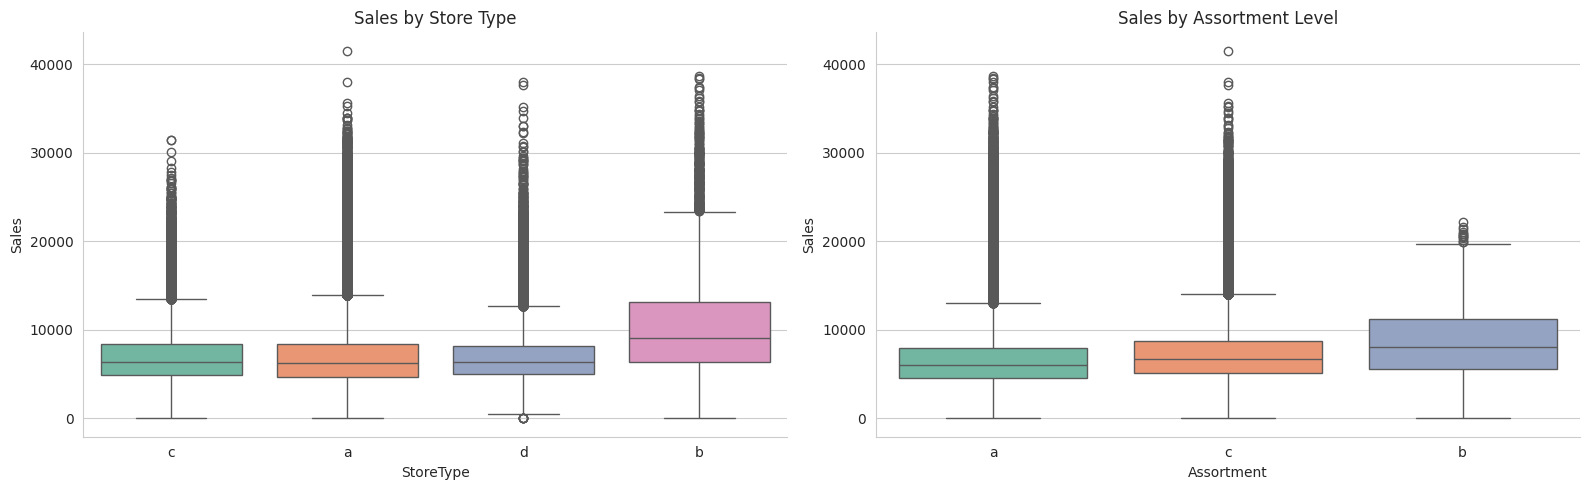

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='StoreType', y='Sales', ax=axes[0],
            palette='Set2', hue='StoreType', legend=False)
axes[0].set_title('Sales by Store Type')

sns.boxplot(data=df, x='Assortment', y='Sales', ax=axes[1],
            palette='Set2', hue='Assortment', legend=False)
axes[1].set_title('Sales by Assortment Level')

plt.tight_layout()
plt.show()

## 7. Stationarity Test (ADF)

In [41]:
daily_sales = df.groupby('Date')['Sales'].mean().sort_index()

adf_result = adfuller(daily_sales.dropna(), autolag='AIC')

print('Augmented Dickey-Fuller Test:')
print(f'  Test Statistic: {adf_result[0]:.4f}')
print(f'  p-value: {adf_result[1]:.6f}')
print(f'  Lags Used: {adf_result[2]}')
for key, value in adf_result[4].items():
    print(f'  Critical Value ({key}): {value:.4f}')

if adf_result[1] < 0.05:
    print('\nConclusion: Series is stationary (p < 0.05).')
else:
    print('\nConclusion: Series is NON-stationary (p >= 0.05). Differencing may be needed for ARIMA.')

Augmented Dickey-Fuller Test:
  Test Statistic: -5.4154
  p-value: 0.000003
  Lags Used: 17
  Critical Value (1%): -3.4374
  Critical Value (5%): -2.8647
  Critical Value (10%): -2.5684

Conclusion: Series is stationary (p < 0.05).


## 8. STL Decomposition

Separates the series into trend, seasonal (weekly cycle), and residual components.

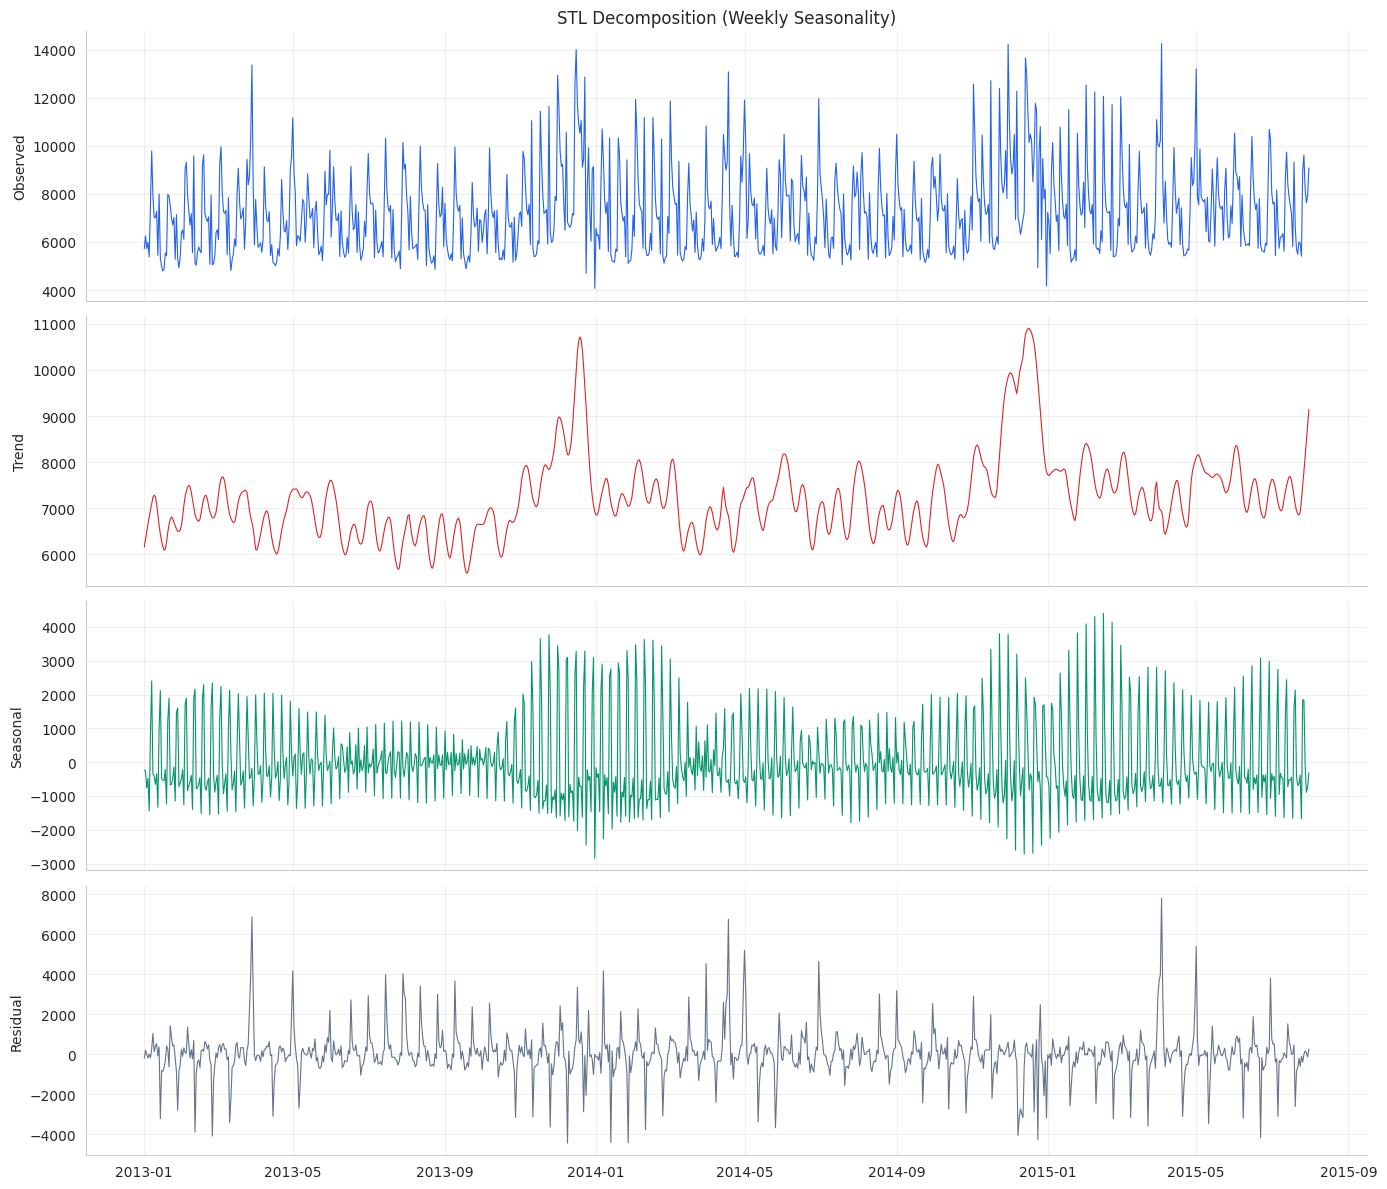

Seasonal strength: 0.359 (explains ~36% of non-residual variation)


In [42]:
stl = STL(daily_sales, period=7, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = [
    ('Observed', stl_result.observed, COLORS['primary']),
    ('Trend', stl_result.trend, COLORS['secondary']),
    ('Seasonal', stl_result.seasonal, COLORS['tertiary']),
    ('Residual', stl_result.resid, COLORS['neutral']),
]
for ax, (name, data, color) in zip(axes, components):
    ax.plot(data, color=color, lw=0.8)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)
axes[0].set_title('STL Decomposition (Weekly Seasonality)')
plt.tight_layout()
plt.show()

seasonal_strength = 1 - (stl_result.resid.var() / (stl_result.seasonal + stl_result.resid).var())
print(f'Seasonal strength: {seasonal_strength:.3f} (explains ~{seasonal_strength*100:.0f}% of non-residual variation)')

## 9. Competition Distance Effect

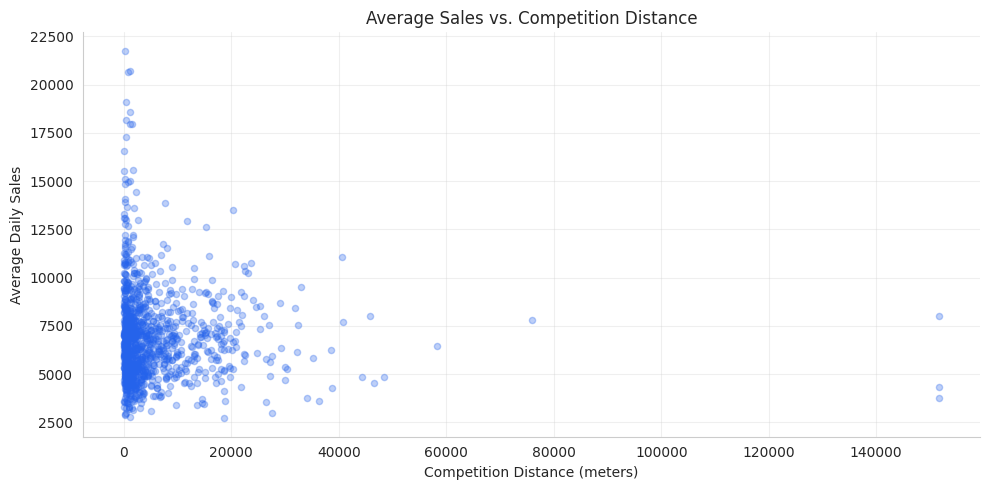

In [43]:
store_avg = df.groupby('Store').agg({'Sales': 'mean', 'CompetitionDistance': 'first'}).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(store_avg['CompetitionDistance'], store_avg['Sales'],
           alpha=0.3, color=COLORS['primary'], s=20)
ax.set_title('Average Sales vs. Competition Distance')
ax.set_xlabel('Competition Distance (meters)')
ax.set_ylabel('Average Daily Sales')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary

### Temporal Patterns
- Strong weekly seasonality (Monday peak, Sunday low)
- Monthly patterns with December spike (holiday shopping)
- Overall trend is relatively stable

### External Factors
- Promotions drive a significant and consistent sales lift
- Holiday effects depend on store closure patterns
- Competition distance has a weak direct relationship

### Store-Level Variation
- Store types and assortment levels have different baseline sales
- This cross-sectional variation can be leveraged by ML models